In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

os.environ['CUDA_VISIBLE_DEVICES'] = '-1'  # Deshabilitar el uso de GPU

import tensorflow as tf   

# 1. Agregas la ruta absoluta de la carpeta externa al sistema de Python
ruta_externa = '/home/asus_juan/Documents/GitHub/Despliegue-modelo-ANN-Turbinas-Hidraulicas/scripts/scr'
sys.path.append(ruta_externa)

from cargar_datos import cargar_datos
from ft_engineering import fix_dataframe, ft_engineering, split_to_model

In [7]:
df = cargar_datos('30Hz_P1')

# Listas de los features a procesar
numerics = ['RPM', 'Torque [Nm]', 'Angle']
negative_nums = ['Torque [Nm]', 'Angle', 'RPM', 'Power [Watts]']
droping_feat = ['RPM_P', 'Power', 'Tracking Value', 'Sample Number', 'Time Elapsed', 'Date'] # Variables innesarias
droping_feat_actual = [col for col in droping_feat if col in df.columns]

df_fixed = fix_dataframe(df, num_feats=(numerics + ['Power [Watts]']), negative_feats=negative_nums)
Pipeline = ft_engineering(var_num=numerics, drop_var=droping_feat_actual, quantile=0.05)
X_train, X_test, y_train, y_test = split_to_model(df_fixed, target='Power [Watts]', stratify=False)

Pipeline.fit(X_train, y_train)

X_train_transformed = Pipeline.transform(X_train)
X_test_transformed = Pipeline.transform(X_test)
print(f"Número de columnas finales para la Red Neuronal: {X_train_transformed.shape[1]}")

Cargados correctamente 663 datos
Variables successfully separated — X: 663 rows, y: 663 rows
Train split size: 530
Test split size:  133
Número de columnas finales para la Red Neuronal: 3


In [10]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train_transformed.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)  # Capa de salida para regresión
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(
    X_train_transformed,
    y_train,
    validation_split = 0.2,
    epochs=150,
    batch_size=32,
    verbose=1
)

# 7. Evaluación final con los datos de prueba
loss, mae = model.evaluate(X_test_transformed, y_test)
print(f"Error Absoluto Medio (MAE) en datos de prueba: {mae:.2f} Watts")

Epoch 1/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2792.1489 - mae: 44.5512 - val_loss: 2516.8608 - val_mae: 42.1459
Epoch 2/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2738.1128 - mae: 43.9901 - val_loss: 2455.4939 - val_mae: 41.4038
Epoch 3/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2667.0715 - mae: 43.2298 - val_loss: 2372.6389 - val_mae: 40.3913
Epoch 4/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2569.1191 - mae: 42.1584 - val_loss: 2257.2766 - val_mae: 38.9671
Epoch 5/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2435.1240 - mae: 40.6459 - val_loss: 2103.1284 - val_mae: 36.9790
Epoch 6/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2255.5618 - mae: 38.5634 - val_loss: 1910.8695 - val_mae: 34.3413
Epoch 7/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2043.7168 - mae: 35.9104 - val_loss: 1689.7615 - val_mae: 31.1046
Epoch 8/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1809.2896 - mae: 32.8333 - val_loss: 1461.7275 - val_mae: 28.3208

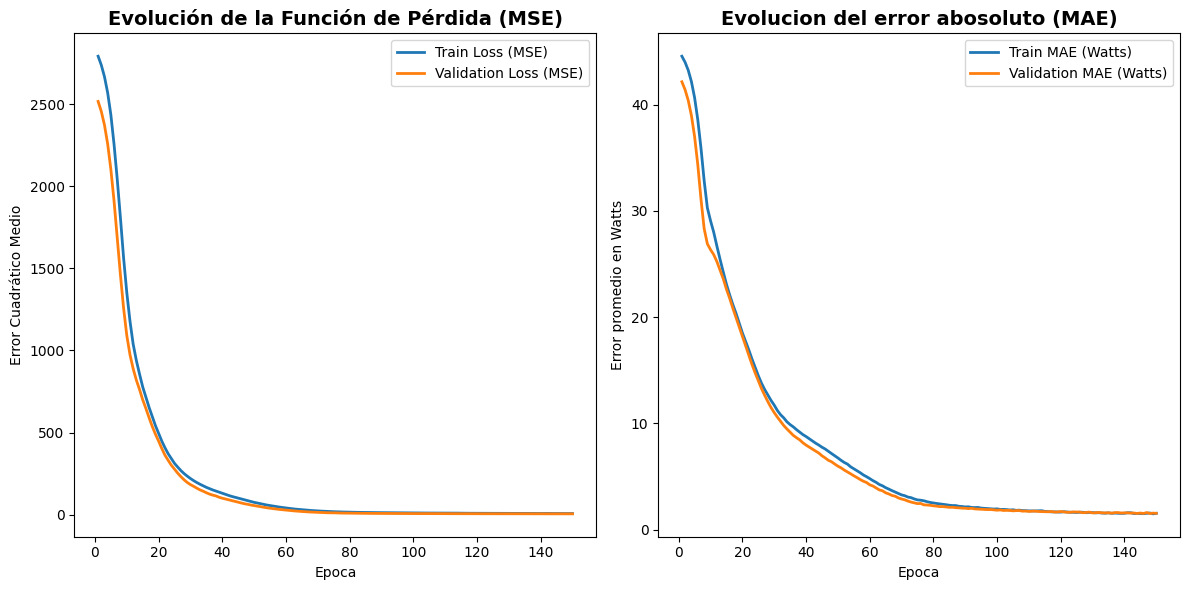

In [15]:
history_df = pd.DataFrame(history.history)
history_df['Epoca'] = history_df.index + 1

fig, ax = plt.subplots(1, 2, figsize=(12,6))

sns.lineplot(data=history_df, x='Epoca', y='loss', label='Train Loss (MSE)', ax=ax[0], linewidth=2)
sns.lineplot(data=history_df, x='Epoca', y='val_loss', label='Validation Loss (MSE)', ax=ax[0], linewidth=2)
ax[0].set_title('Evolución de la Función de Pérdida (MSE)', fontsize=14, fontweight='bold')
ax[0].set_ylabel('Error Cuadrático Medio')

sns.lineplot(data=history_df, x='Epoca', y='mae', label='Train MAE (Watts)', ax=ax[1], linewidth=2)
sns.lineplot(data=history_df, x='Epoca', y='val_mae', label='Validation MAE (Watts)', ax=ax[1], linewidth=2)
ax[1].set_title('Evolucion del error abosoluto (MAE)', fontsize=14, fontweight='bold')
ax[1].set_ylabel('Error promedio en Watts')

plt.tight_layout()
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


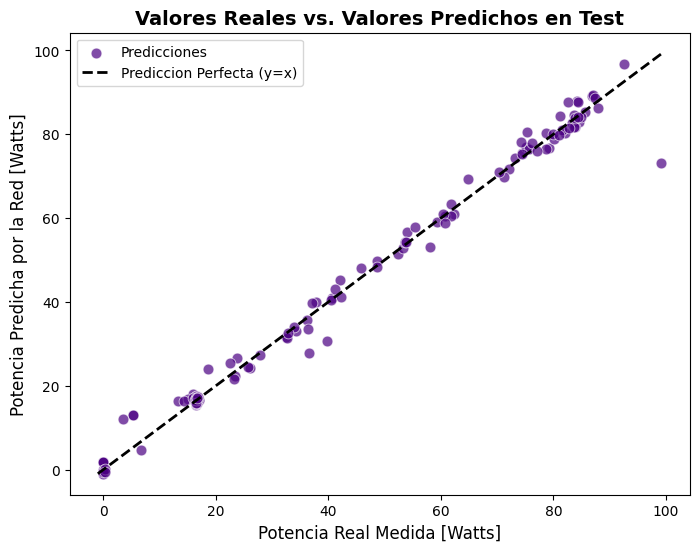

In [16]:
y_pred = model.predict(X_test_transformed).flatten()

plt.figure(figsize=(8,6))

sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color='indigo', s=60, label='Predicciones')

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
sns.lineplot(x=[min_val, max_val], y=[min_val, max_val], color='black', linestyle='--', linewidth=2, label='Prediccion Perfecta (y=x)')

plt.title('Valores Reales vs. Valores Predichos en Test', fontsize=14, fontweight='bold')
plt.xlabel('Potencia Real Medida [Watts]', fontsize=12)
plt.ylabel('Potencia Predicha por la Red [Watts]', fontsize=12)
plt.legend(loc='upper left')
plt.show()

In [21]:
# Debido a las versiones de Pandas y de Feature-Engine se tiene que crear un dataframe con la misma forma del original
caso_especifico = pd.DataFrame(columns=X_train.columns)

# Agregamos una fila llena de ceros
caso_especifico.loc[0] = 0.0 

# Escribimos solo las variables que nos importa agregar
caso_especifico.loc[0, 'RPM'] = 793
caso_especifico.loc[0, 'Torque [Nm]'] = 0.198
caso_especifico.loc[0, 'Angle'] = 70302

# Transformamos usando el Pipeline ya ajustado
caso_transformado = Pipeline.transform(caso_especifico)

# Predicción
prediccion_watts = model.predict(caso_transformado)

print("\n" + "="*45)
print(" RESULTADO DEL CASO")
print("="*45)
print("Parámetros de entrada de la turbina:")
print(f" - RPM: {caso_especifico.loc[0, 'RPM']}")
print(f" - Torque [Nm]: {caso_especifico.loc[0, 'Torque [Nm]']}")
print(f" - Angle: {caso_especifico.loc[0, 'Angle']}")
    
print(f"\n POTENCIA GENERADA PREDICHA: {prediccion_watts[0][0]:.2f} Watts")
print("="*45)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

 RESULTADO DEL CASO
Parámetros de entrada de la turbina:
 - RPM: 793.0
 - Torque [Nm]: 0.198
 - Angle: 70302.0

 POTENCIA GENERADA PREDICHA: 15.78 Watts
